# Monte Carlo Simulation

Generating 2000000 random numbers...
Simulated 1000 samples of size 100.


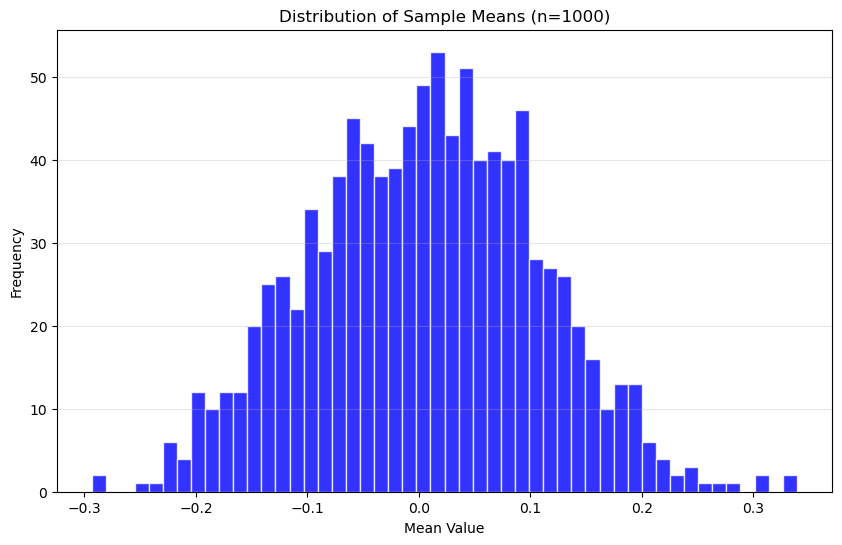

In [17]:
import numpy as np
import matplotlib.pyplot as plt

class MonteCarloSimulator:
    def __init__(self):
        self.data_pool = None
        self.means = None

    def create_source_data(self, size=1000000):
        """Generates the initial Standard Normal pool."""
        print(f"Generating {size} random numbers...")
        self.data_pool = np.random.standard_normal(size)

    def run_simulation(self, n, m):
        """Perform n simulations of size m and store the means."""
        if self.data_pool is None:
            print("Error: Create source data first!")
            return

        if n * m > len(self.data_pool):
            print(f"Warning: n*m is larger than data pool. Generating more data...")
            self.create_source_data(n * m)

        # Grab slice, reshape to (n, m), and calculate mean of each row
        samples = self.data_pool[:n*m].reshape(n, m)
        self.means = samples.mean(axis=1)
        print(f"Simulated {n} samples of size {m}.")

    def plot_results(self, color='royalblue'):
        """Visualizes the distribution of the gathered means."""
        if self.means is None:
            print("Error: Run simulation first!")
            return

        plt.figure(figsize=(10, 6))
        plt.hist(self.means, bins=50, color=color, edgecolor='white', alpha=0.8)
        plt.title(f"Distribution of Sample Means (n={len(self.means)})")
        plt.xlabel("Mean Value")
        plt.ylabel("Frequency")
        plt.grid(axis='y', alpha=0.3)
        plt.show()

# --- Example Usage ---
sim = MonteCarloSimulator()

# 1. Create the pool once
sim.create_source_data(size=2000000)

# 2. Run with small n and m
sim.run_simulation(n=1000, m=100)
sim.plot_results(color='blue')